In [1]:
import torch
import torch.nn as nn
from skrl.models.torch import GaussianMixin, Model
from skrl.utils.spaces.torch import unflatten_tensorized_space
from gymnasium import spaces
import gymnasium as gym
import numpy as np

action_space = spaces.Box(low=-7.5, high=7.5, shape=(2,), dtype=np.float32)
observation_space = spaces.Box(low=-0.0, high=1.0, shape=(3, 64, 64), dtype=np.float32)

class GaussianModel(GaussianMixin, Model):
    def __init__(self, observation_space, action_space, device, clip_actions=False,
                 clip_log_std=True, min_log_std=-2, max_log_std=2, reduction="sum"):
        Model.__init__(self, observation_space, action_space, device)
        GaussianMixin.__init__(self, clip_actions, clip_log_std, min_log_std, max_log_std, reduction)

        # Note: We use Lazy layers, so we must do a dummy pass before loading weights
        self.net_container = nn.Sequential(
            nn.LazyConv2d(out_channels=64, kernel_size=5, stride=2),
            nn.ELU(),
            nn.LazyConv2d(out_channels=128, kernel_size=3, stride=2),
            nn.ELU(),
            nn.LazyConv2d(out_channels=128, kernel_size=3, stride=1),
            nn.ELU(),
            nn.Flatten(),
            nn.LazyLinear(out_features=1024),
            nn.ELU(),
            nn.LazyLinear(out_features=1024),
            nn.ELU(),
            nn.LazyLinear(out_features=self.num_actions),
        )
        self.log_std_parameter = nn.Parameter(torch.full(size=(self.num_actions,), fill_value=0.0), requires_grad=True)

    def compute(self, inputs, role=""):
        # The unflatten utility handles the conversion from a flat tensor to 
        # the (C, H, W) shape expected by your Conv2d layers.
        states = unflatten_tensorized_space(self.observation_space, inputs.get("states"))
        output = self.net_container(states)
        
        return output, self.log_std_parameter, {}


# 2. Instantiate and Load Weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

# Replace obs_space and act_space with your environment's actual dimensions
policy = GaussianModel(observation_space, action_space, device)

# Load the checkpoint6
checkpoint = torch.load('agent_25000.pt', map_location=device)
policy.load_state_dict(checkpoint['policy']) # skrl stores it under 'policy'
policy.eval()

dummy_input = {"states": torch.zeros((1, 3, 64, 64)).to(device)}
policy.compute(dummy_input)

/tmp/ipykernel_3631/1665612526.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('agent_25000.pt', map_location=device)


(tensor([[7.9996, 8.7866]], grad_fn=<AddmmBackward0>),
 Parameter containing:
 tensor([0.9457, 0.9442], requires_grad=True),
 {})

In [2]:
from jetbot import Camera
from jetbot import Robot

robot = Robot()
camera_0 = Camera.instance(sensor_id=1)
camera_1 = Camera.instance(sensor_id=0)

self.sensor_id:  1
GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3280 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3280 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: Running with following settings:
   Camera index = 1 
   Camera mode  = 3 
   Output St

[ WARN:0@2.437] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3280 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3280 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: Running with following settings:
   Camera index = 0 
   Camera mode  = 3 
   Output Stream W = 1640 H = 1

[ WARN:0@3.029] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


In [3]:
import cv2

image_0 = camera_0.value[:, :, :3]
print("image_0.shape: ", image_0.shape)
image_0_gray = cv2.cvtColor(image_0, cv2.COLOR_BGR2GRAY)
image_0_gray = cv2.flip(image_0_gray, -1)
image_0_resized = cv2.resize(image_0_gray, (64, 64), interpolation=cv2.INTER_AREA)

#image_0 = Image.fromarray(np.uint8(image_0))

image_1 = camera_1.value[:, :, :3]
image_1_gray = cv2.cvtColor(image_1, cv2.COLOR_BGR2GRAY)
image_1_gray = cv2.flip(image_1_gray, -1)
image_1_resized = cv2.resize(image_1_gray, (64, 64), interpolation=cv2.INTER_AREA)
#image_1 = Image.fromarray(np.uint8(image_1))

image_0.shape:  (480, 640, 3)


image_0_resized.shape:  (64, 64)


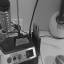

In [4]:
from IPython.display import display, HTML, clear_output
from IPython.display import Image as IPython_Image

def arrayShow(imageArray):
    image = bytes(cv2.imencode('.jpg', imageArray)[1])
    return IPython_Image(data=image)

print("image_0_resized.shape: ", image_0_resized.shape)
arrayShow(image_0_resized)

image_1_resized.shape:  (64, 64)


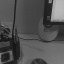

In [5]:
print("image_1_resized.shape: ", image_1_resized.shape)
arrayShow(image_1_resized)

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

def get_scalar_observation():
    forward_speed = robot.get_forward_speed()
    
    # Target dimensions (matching your camera images)
    H, W = 64, 64
    
    # Create a 64x64 layer where every pixel is 0.0975
    # This is the equivalent of view(1, 1, 1, 1).expand(-1, -1, 64, 64)
    speed_map = np.full((H, W), forward_speed, dtype=np.float32)
    
    # If you need to stack it, add a channel dimension to make it (1, 64, 64)
    speed_map = speed_map[np.newaxis, :, :]
    #print("speed_map.shape: ", speed_map.shape)

    return speed_map

scalar_observation = get_scalar_observation()
#print("scalar_observation.shape: ", scalar_observation.shape)


def get_observation():
    image_0 = camera_0.value[:, :, :3]
    image_0_gray = cv2.cvtColor(image_0, cv2.COLOR_BGR2GRAY)
    image_0_gray = cv2.flip(image_0_gray, -1)
    image_0_resized = cv2.resize(image_0_gray, (64, 64), interpolation=cv2.INTER_AREA)
    image_0_resized = np.expand_dims(image_0_resized, 0) / 255.0
    #print("image_0_resized.shape: ", image_0_resized.shape)
    
    image_1 = camera_1.value[:, :, :3]
    image_1_gray = cv2.cvtColor(image_1, cv2.COLOR_BGR2GRAY)
    image_1_gray = cv2.flip(image_1_gray, -1)
    image_1_resized = cv2.resize(image_1_gray, (64, 64), interpolation=cv2.INTER_AREA)
    image_1_resized = np.expand_dims(image_1_resized, 0) / 255.0
    #print("image_1_resized.shape: ", image_1_resized.shape)

    scalar_observation = get_scalar_observation()
    
    #camera_observation = np.concatenate((image_0_resized, image_1_resized), axis=0)
    observation = np.concatenate((image_0_resized, scalar_observation), axis=0)
    observation = np.concatenate((observation, image_1_resized), axis=0)
    #print("camera_observation.shape: ", camera_observation.shape)

    # 2. Create a side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(5, 5))
    
    # Camera 0 (Channel 0)
    axes[0].imshow(image_0_resized[0], cmap='gray')
    axes[0].set_title("Camera 0 (64x64)")
    axes[0].axis('off')
    
    # Camera 1 (Channel 1)
    axes[1].imshow(image_1_resized[0], cmap='gray')
    axes[1].set_title("Camera 1 (64x64)")
    axes[1].axis('off')
    
    plt.show()

    clear_output(wait=True)
    
    return torch.from_numpy(observation).to('cpu').unsqueeze(0).float()

observation = get_observation()
print("observation.shape: ", observation.shape)

observation.shape:  torch.Size([1, 3, 64, 64])


In [7]:
robot.set_motors(0.2, 0.2)

In [12]:
robot.set_motors(0.0, 0.0)

In [9]:
robot.get_forward_speed()

0.0

In [16]:
import cv2

'''
def get_observation():
    # Replace with your actual observation logic from simulation
    # e.g., [left_speed, right_speed, sensor_data...]
    #obs = np.ones([1, 3, 64, 64]) * 255.0
    camera_observation = get_camera_observation()
    #print("camera_observation.shape: ", camera_observation.shape)

    scalar_observation = get_scalar_observation()
    #print("scalar_observation.shape: ", scalar_observation.shape)

    observation = np.concatenate((camera_observation, scalar_observation), axis=0)
    #print("observation.shape: ", observation.shape)
    
    return torch.from_numpy(observation).to('cpu').unsqueeze(0).float()
'''

try:
    while True:
        #obs = get_observation()
        obs = get_observation()
        #print("obs: ", obs)
        
        # 2. Run Inference
        with torch.no_grad():
            action, _, _ = policy.act({"states": obs}, role="policy")

        # Convert the tensor to a numpy array for the robot motors
        action_np = action.cpu().numpy()[0]
        print("action_np: ", action_np)
        
        action_np = np.clip(action_np, -7.5, 7.5) / 30.0

        #print("action_np: ", action_np)
        #print("")
        
        # 3. Apply Actions
        robot.set_motors(float(action_np[0]), float(action_np[1]))

except KeyboardInterrupt:
    robot.stop()

action_np:  [6.3137507 9.036217 ]
